Loaded 99 movies


Fetching genre & keywords: 100%|██████████| 99/99 [00:26<00:00,  3.72it/s]


Saved 'movie_nights_enriched.csv'


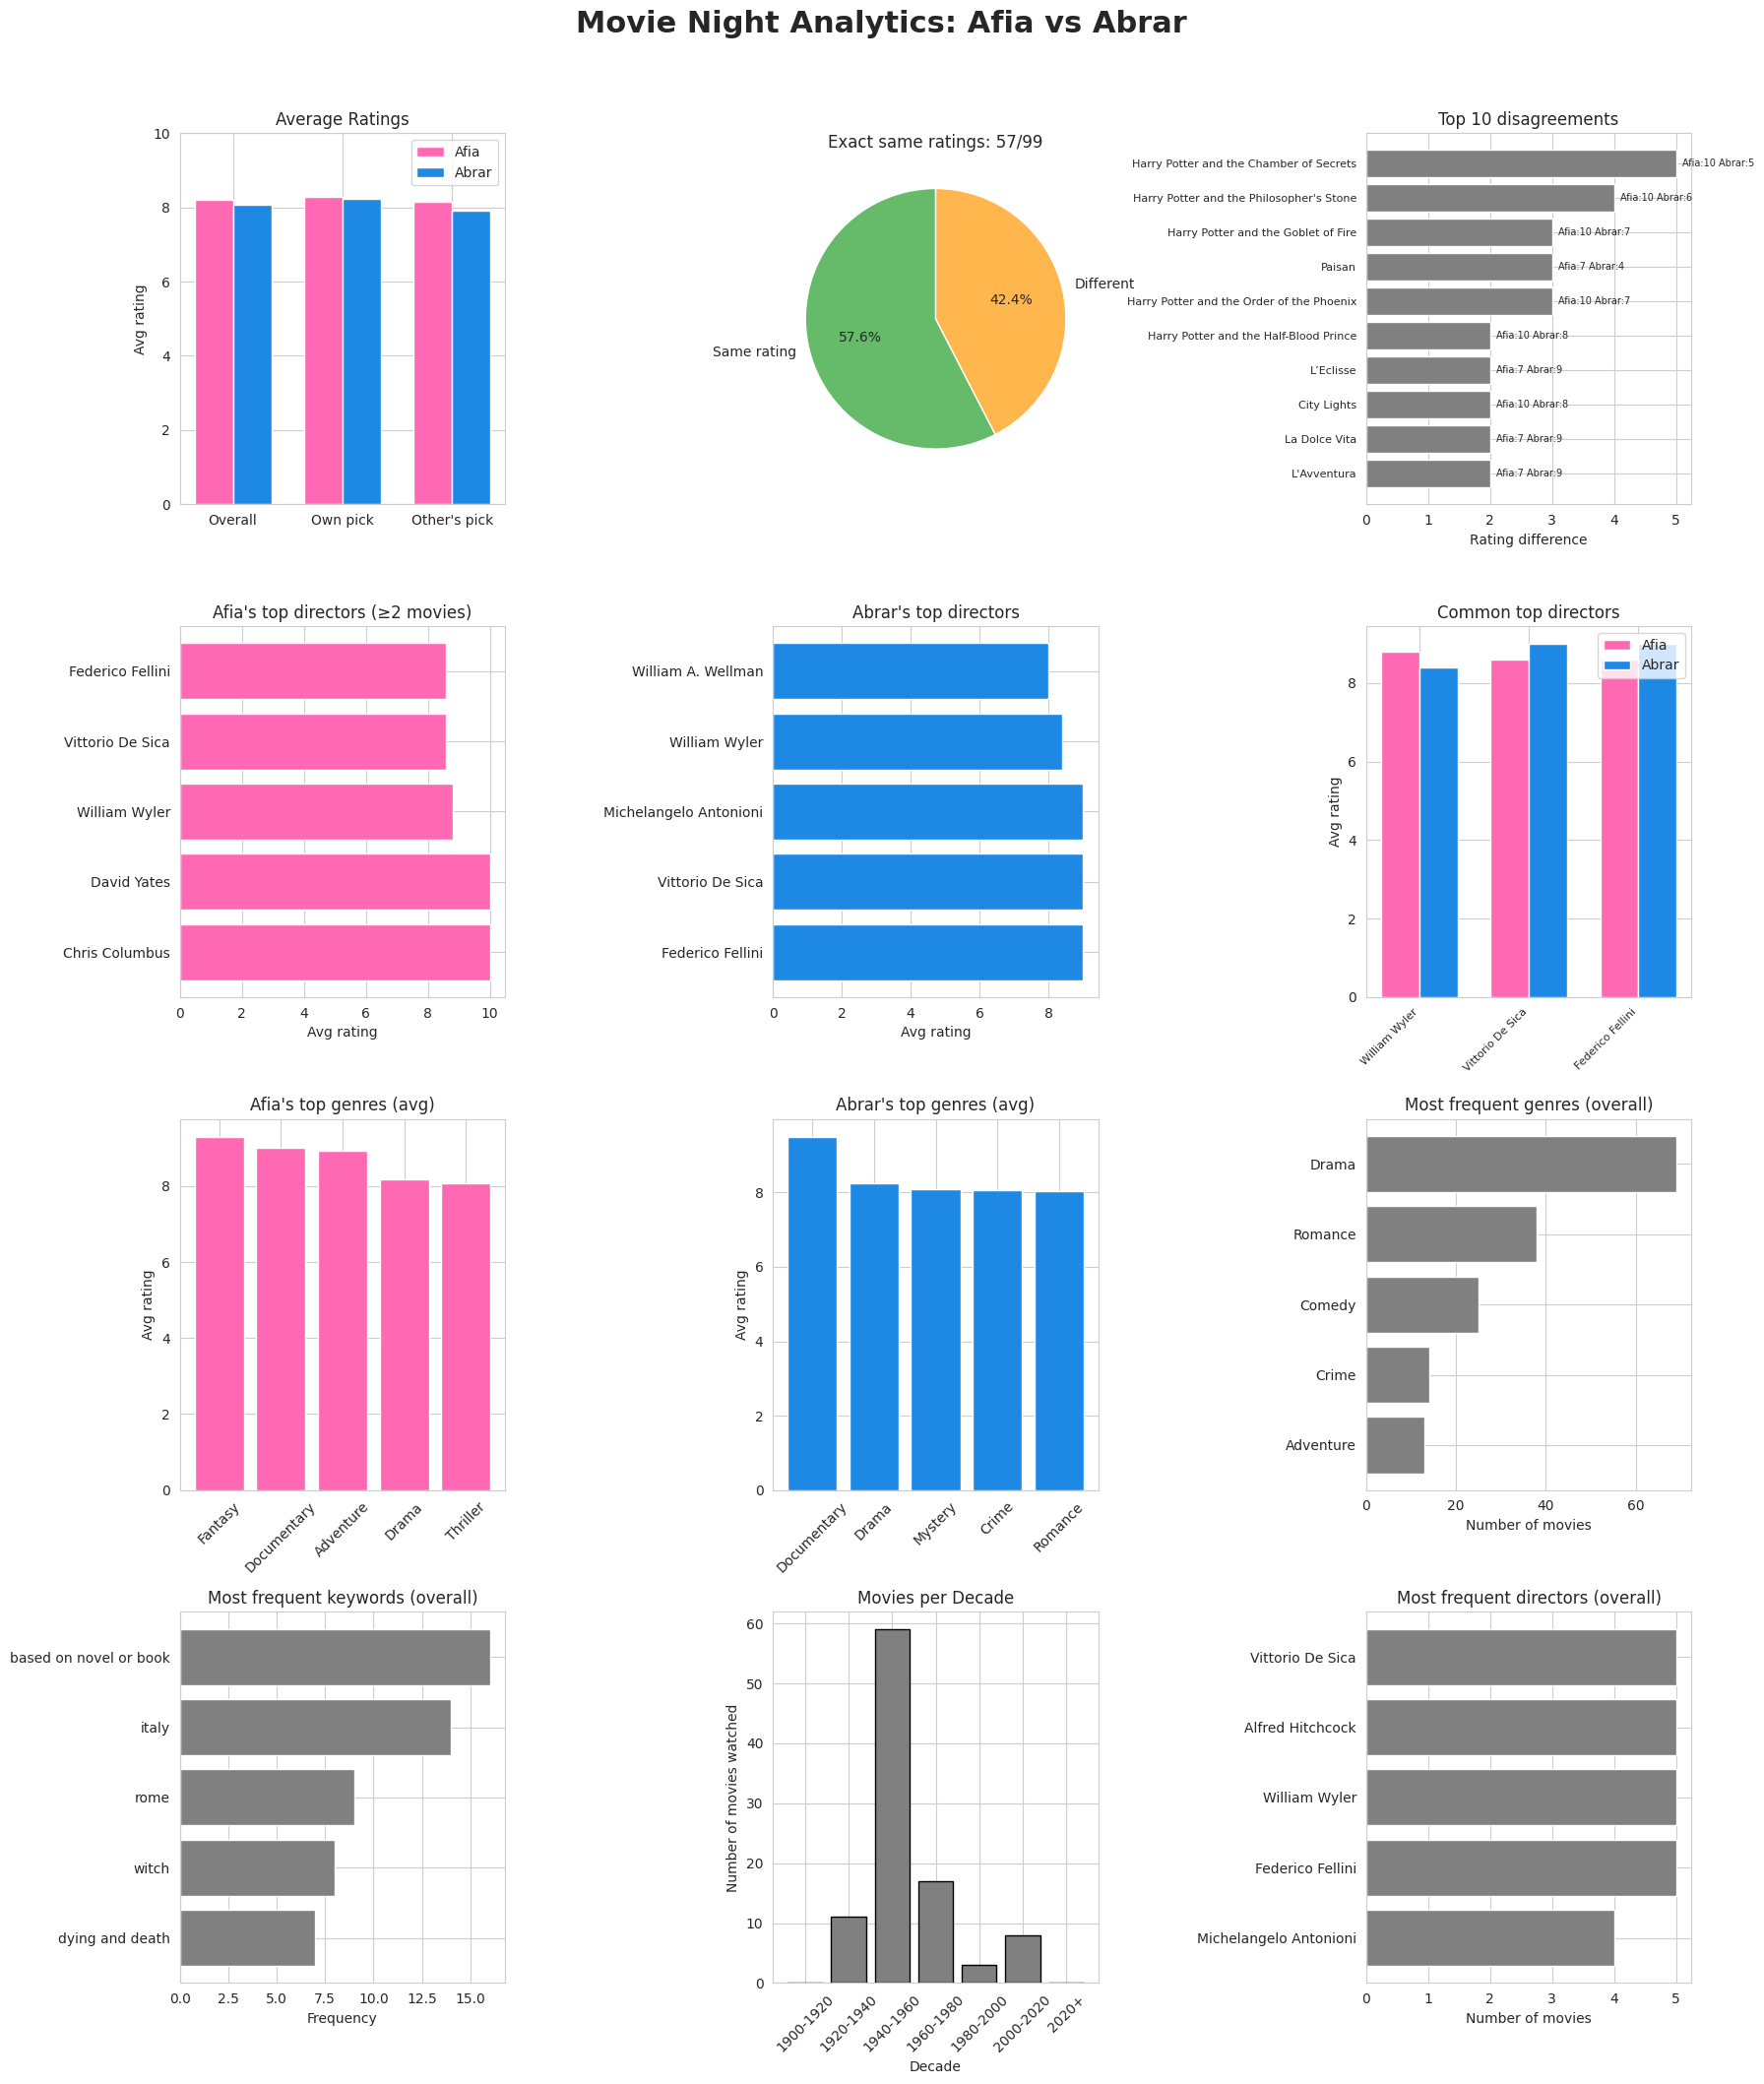

✅ Done! Files: movie_night_analytics.png / .svg


In [6]:
# =====================================================
# MOVIE NIGHT ANALYTICS – FINAL (with existing Director & Year)
# =====================================================

# 1. Install & import
!pip install pandas matplotlib seaborn scikit-learn requests tqdm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.linear_model import LinearRegression
import requests
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Colors
afia_color = '#FF69B4'
abrar_color = '#1E88E5'
sns.set_style("whitegrid")

# =====================================================
# STEP 1: PASTE YOUR NOTION TABLE (6 columns)
# =====================================================
# Replace the string below with your actual table.
# Columns order: SL, Movie, Director, Release Year, Afia’s Rating, Abrar’s Rating
# Use CSV format (comma separated) or copy as is.

notion_csv = """
SL,Movie,Director,Release Year,Afia’s Rating,Abrar’s Rating
1,The Shop Around the Corner,Ernst Lubitsch,1940,8,8
2,Citizen Kane,Orson Welles,1941,10,10
3,Casablanca,Michael Curtiz,1943,8,8
4,Bicycle Thieves,Vittorio De Sica,1948,10,10
5,12 Angry Men,Sidney Lumet,1957,10,10
6,The Golden Coach,Jean Renoir,1952,7,7
7,North by Northwest,Alfred Hitchcock,1959,8,8
8,Umberto D.,Vittorio De Sica,1952,10,10
9,The General,Clyde Bruckman,1926,8,7
10,Miracle in Milan,Vittorio De Sica,1951,6,7
11,City Lights,Charlie Chaplin,1931,10,8
12,L'Avventura,Michelangelo Antonioni,1960,7,9
13,The Lady Vanishes,Alfred Hitchcock,1938,8,7
14,Bellissima,Luchino Visconti,1951,8,8
15,The Wizard of Oz,Victor Fleming,1939,7,6
16,Shoeshine,Tom Abrams,1987,8,9
17,Rebecca,Alfred Hitchcock,1940,7,8
18,It Happened One Night,Frank Capra,1934,7,6
19,The Grapes of Wrath,John Ford,1940,8,8
20,"Rome, Open City",Roberto Rossellini,1945,8,8
21,Shadow of a Doubt,Alfred Hitchcock,1943,7,7
22,Paisan,Roberto Rossellini,1946,7,4
23,Sunset Blvd.,Matthew Miller,2019,9,10
24,Germany Year Zero,Roberto Rossellini,1948,9,8
25,Some Like It Hot,Billy Wilder,1959,8,8
26,Roman Holiday,William Wyler,1953,9,8
27,On the Waterfront,Elia Kazan,1954,7,7
28,The Lost Weekend,Billy Wilder,1945,7,7
29,The Apartment,Billy Wilder,1960,8,9
30,Sabrina,Sydney Pollack,1995,7,7
31,Singin' in the Rain,Stanley Donen,1952,8,8
32,La Strada,Federico Fellini,1954,9,10
33,La Jetée,Chris Marker,1962,8,8
34,Nights of Cabiria,Federico Fellini,1957,10,9
35,La Dolce Vita,Federico Fellini,1960,7,9
36,I Vitelloni,Federico Fellini,1953,8,8
37,Remember the Night,Mitchell Leisen,1940,8,8
38,La Terra Trema,Luchino Visconti,1949,8,7
39,"Now, Voyager",Irving Rapper,1942,8,8
40,Bitter Rice,Giuseppe De Santis,1949,7,7
41,The Young in Heart,Richard Wallace,1938,8,8
42,Brief Encounter,David Lean,1945,8,8
43,Children of Paradise,Marcel Carné,1945,8,9
44,The Asphalt Jungle,John Huston,1950,7,6
45,Breakfast at Tiffany's,Blake Edwards,1961,8,8
46,Il Sorpasso,Dino Risi,1962,9,9
47,The Philadelphia Story,George Cukor,1940,8,7
48,Divorzio all'italiana,Pietro Germi,1961,8,9
49,Laura,Otto Preminger,1944,8,8
50,Journey to Italy,Roberto Rossellini,1954,8,8
51,All About Eve,Joseph L. Mankiewicz,1950,9,9
52,A Special Day,Ettore Scola,1977,9,9
53,Meet Me in St. Louis,Vincente Minnelli,1944,7,7
54,Letter from an Unknown Woman,Max Ophüls,1948,7,8
55,Girl Crazy,Mack Sennett,1929,6,6
56,Aranyer Din Ratri,Satyajit Ray,1970,8,8
57,Stagecoach,John Ford,1939,8,8
58,Ossessione,Luchino Visconti,1944,7,8
59,A Streetcar Named Desire,Elia Kazan,1951,9,9
60,Le Notti Bianche,Luchino Visconti,1957,10,9
61,How to Steal a Million,William Wyler,1966,9,9
62,Il Posto,Ermanno Olmi,1961,7,8
63,The Night of the Hunter,Charles Laughton,1955,8,8
64,La Notte,Michelangelo Antonioni,1961,9,9
65,The Maltese Falcon,John Huston,1941,8,8
66,Les Quatre Cents Coups,François Truffaut,1959,10,10
67,Sirocco,Curtis Bernhardt,1951,8,8
68,I Fidanzati,Ermanno Olmi,1963,7,8
69,Dial M for Murder,Alfred Hitchcock,1954,9,9
70,L’Eclisse,Michelangelo Antonioni,1962,7,9
71,His Girl Friday,Howard Hawks,1940,8,8
72,Dodsworth,William Wyler,1936,9,9
73,Wings,William A. Wellman,1927,8,8
74,The Heiress,William Wyler,1949,8,7
75,The 39 Steps,Ralph Thomas,1959,7,7
76,Il Grido,Michelangelo Antonioni,1957,8,9
77,The Man Who Knew Too Much,Yadollah Samadi,1984,8,8
78,Il Bidone,Federico Fellini,1955,9,9
79,A Place in the Sun,George Stevens,1951,9,9
80,All That Heaven Allows,Tai Paulo,,7,7
81,Harry Potter and the Philosopher's Stone,Chris Columbus,2001,10,6
82,Marty,Delbert Mann,1955,8,9
83,Harry Potter and the Chamber of Secrets,Chris Columbus,2002,10,5
84,In a Lonely Place,Nicholas Ray,1950,9,8
85,Harry Potter and the Goblet of Fire,Mike Newell,2005,10,7
86,It's a Wonderful Life,Frank Capra,1946,10,10
87,Harry Potter and the Order of the Phoenix,David Yates,2007,10,7
88,Il Tetto,Vittorio De Sica,1956,8,8
89,Harry Potter and the Half-Blood Prince,David Yates,2009,10,8
90,Mouchette,Robert Bresson,1967,5,6
91,Harry Potter and the Deathly Hallows Part 1,David Yates,2010,10,8
92,The Third Man,Carol Reed,1949,9,9
93,Harry Potter and the Deathly Hallows: Part 2,David Yates,2011,10,9
94,La Ciociara,Vittorio De Sica,1960,9,10
95,To Have and Have Not,Howard Hawks,1945,6,7
96,Paths of Glory,Stanley Kubrick,1957,9,9
97,Wuthering Heights,William Wyler,1939,9,9
98,The Ox-Bow Incident,William A. Wellman,1943,8,8
99,The Conversation,Francis Ford Coppola,1974,8,8
"""

# Load
from io import StringIO
df = pd.read_csv(StringIO(notion_csv))
df.columns = ['week', 'movie_title', 'director', 'release_year', 'rating_afia', 'rating_abrar']
df['rating_afia'] = pd.to_numeric(df['rating_afia'], errors='coerce')
df['rating_abrar'] = pd.to_numeric(df['rating_abrar'], errors='coerce')
df['selector'] = df['week'].apply(lambda x: 'Afia' if x % 2 == 1 else 'Abrar')
print(f"Loaded {len(df)} movies")

# =====================================================
# STEP 2: ADD GENRE & KEYWORDS FROM TMDB
# =====================================================
TMDB_API_KEY = "cb556f01863d7ce299c50fddae53b3f0"   # <-- REPLACE

def get_genre_keywords(title, api_key):
    base = "https://api.themoviedb.org/3/search/movie"
    params = {'api_key': api_key, 'query': title}
    try:
        resp = requests.get(base, params=params, timeout=5)
        if resp.status_code != 200:
            return None, None
        results = resp.json().get('results')
        if not results:
            return None, None
        movie = results[0]
        movie_id = movie['id']
        # Genres
        genre_ids = movie.get('genre_ids', [])
        genre_url = "https://api.themoviedb.org/3/genre/movie/list"
        genre_resp = requests.get(genre_url, params={'api_key': api_key})
        genre_map = {g['id']: g['name'] for g in genre_resp.json().get('genres', [])}
        genres = ', '.join([genre_map.get(gid, '') for gid in genre_ids])
        # Keywords
        kw_url = f"https://api.themoviedb.org/3/movie/{movie_id}/keywords"
        kw_resp = requests.get(kw_url, params={'api_key': api_key})
        keywords = []
        if kw_resp.status_code == 200:
            keywords = [k['name'] for k in kw_resp.json().get('keywords', [])[:3]]
        keywords_str = ', '.join(keywords) if keywords else None
        return genres, keywords_str
    except:
        return None, None

genres_list = []
keywords_list = []
for title in tqdm(df['movie_title'], desc="Fetching genre & keywords"):
    g, k = get_genre_keywords(title, TMDB_API_KEY)
    genres_list.append(g)
    keywords_list.append(k)
    time.sleep(0.1)

df['genre'] = genres_list
df['keywords'] = keywords_list

# Save enriched data
df.to_csv('movie_nights_enriched.csv', index=False)
print("Saved 'movie_nights_enriched.csv'")

# =====================================================
# STEP 3: ANALYSIS & VISUAL COMPARISONS
# =====================================================
def split_field(field_str):
    if pd.isna(field_str) or not field_str:
        return []
    return [x.strip() for x in str(field_str).split(',')]

df_clean = df.dropna(subset=['rating_afia', 'rating_abrar']).copy()
df_clean['rating_diff'] = np.abs(df_clean['rating_afia'] - df_clean['rating_abrar'])

# --- Basic stats ---
avg_afia = df_clean['rating_afia'].mean()
avg_abrar = df_clean['rating_abrar'].mean()
afia_own = df_clean[df_clean['selector']=='Afia']['rating_afia'].mean()
afia_other = df_clean[df_clean['selector']=='Abrar']['rating_afia'].mean()
abrar_own = df_clean[df_clean['selector']=='Abrar']['rating_abrar'].mean()
abrar_other = df_clean[df_clean['selector']=='Afia']['rating_abrar'].mean()
same = (df_clean['rating_afia'] == df_clean['rating_abrar']).sum()
total = len(df_clean)
pct_same = 100 * same / total
top_diff = df_clean.nlargest(10, 'rating_diff')[['movie_title', 'rating_afia', 'rating_abrar', 'rating_diff']]

# --- Director analysis (using existing director column) ---
def top_directors_avg(df, rating_col, min_movies=2):
    dir_rating = df.dropna(subset=['director']).groupby('director')[rating_col].agg(['mean', 'count'])
    dir_rating = dir_rating[dir_rating['count'] >= min_movies]
    return dir_rating.sort_values('mean', ascending=False).head(5)

top_afia_dirs = top_directors_avg(df_clean, 'rating_afia')
top_abrar_dirs = top_directors_avg(df_clean, 'rating_abrar')
common_dirs = set(top_afia_dirs.index).intersection(set(top_abrar_dirs.index))

# --- Most frequent directors (overall) ---
all_directors = df_clean['director'].dropna().tolist()
director_counts = Counter(all_directors)
top_directors_freq = [d for d, _ in director_counts.most_common(5)]

# --- Genre frequency & average ratings ---
all_genres_list = []
for genres_str in df_clean['genre'].dropna():
    all_genres_list.extend(split_field(genres_str))
genre_counts = Counter(all_genres_list)
top_genres_freq = [g for g, _ in genre_counts.most_common(5)]

def genre_avg_rating(df, rating_col):
    genre_ratings = []
    for _, row in df.iterrows():
        for g in split_field(row['genre']):
            genre_ratings.append((g, row[rating_col]))
    if not genre_ratings:
        return pd.Series()
    genre_df = pd.DataFrame(genre_ratings, columns=['genre', 'rating'])
    return genre_df.groupby('genre')['rating'].mean().sort_values(ascending=False).head(5)

top_genres_afia_avg = genre_avg_rating(df_clean, 'rating_afia')
top_genres_abrar_avg = genre_avg_rating(df_clean, 'rating_abrar')


# --- Keyword frequency ---
all_keywords_list = []
for kw_str in df_clean['keywords'].dropna():
    all_keywords_list.extend(split_field(kw_str))
keyword_counts = Counter(all_keywords_list)
top_keywords = [k for k, _ in keyword_counts.most_common(5)]
# --- Release year range & relation ---
df_year = df_clean.dropna(subset=['release_year']).copy()
df_year['release_year'] = pd.to_numeric(df_year['release_year'], errors='coerce')
df_year = df_year.dropna(subset=['release_year'])

# =====================================================
# STEP 4: CREATE COMPREHENSIVE FIGURE (PNG + SVG)
# =====================================================
fig = plt.figure(figsize=(18, 22))
fig.suptitle('Movie Night Analytics: Afia vs Abrar', fontsize=22, fontweight='bold')

# 1. Average ratings
ax1 = fig.add_subplot(4, 3, 1)
cats = ['Overall', 'Own pick', "Other's pick"]
a_vals = [avg_afia, afia_own, afia_other]
b_vals = [avg_abrar, abrar_own, abrar_other]
x = np.arange(len(cats))
w = 0.35
ax1.bar(x - w/2, a_vals, w, label='Afia', color=afia_color)
ax1.bar(x + w/2, b_vals, w, label='Abrar', color=abrar_color)
ax1.set_ylabel('Avg rating')
ax1.set_title('Average Ratings')
ax1.set_xticks(x)
ax1.set_xticklabels(cats)
ax1.legend()
ax1.set_ylim(0,10)

# 2. Same ratings pie
ax2 = fig.add_subplot(4, 3, 2)
ax2.pie([pct_same, 100-pct_same], labels=['Same rating', 'Different'], autopct='%1.1f%%', colors=['#66BB6A', '#FFB74D'], startangle=90)
ax2.set_title(f'Exact same ratings: {same}/{total}')

# 3. Top disagreements
ax3 = fig.add_subplot(4, 3, 3)
if not top_diff.empty:
    td = top_diff.sort_values('rating_diff', ascending=True)
    ypos = np.arange(len(td))
    ax3.barh(ypos, td['rating_diff'], color='gray')
    ax3.set_yticks(ypos)
    ax3.set_yticklabels(td['movie_title'], fontsize=8)
    ax3.set_xlabel('Rating difference')
    ax3.set_title('Top 10 disagreements')
    for i, (_, row) in enumerate(td.iterrows()):
        ax3.text(row['rating_diff']+0.1, i, f"Afia:{row['rating_afia']} Abrar:{row['rating_abrar']}", va='center', fontsize=7)
else:
    ax3.text(0.5,0.5,'No data',ha='center')

# 4. Afia's top directors (by avg)
ax4 = fig.add_subplot(4, 3, 4)
if not top_afia_dirs.empty:
    ax4.barh(top_afia_dirs.index, top_afia_dirs['mean'], color=afia_color)
    ax4.set_xlabel('Avg rating')
    ax4.set_title("Afia's top directors (≥2 movies)")
else:
    ax4.text(0.5,0.5,'No data',ha='center')

# 5. Abrar's top directors
ax5 = fig.add_subplot(4, 3, 5)
if not top_abrar_dirs.empty:
    ax5.barh(top_abrar_dirs.index, top_abrar_dirs['mean'], color=abrar_color)
    ax5.set_xlabel('Avg rating')
    ax5.set_title("Abrar's top directors")
else:
    ax5.text(0.5,0.5,'No data',ha='center')

# 6. Common directors
ax6 = fig.add_subplot(4, 3, 6)
if common_dirs:
    common_data = []
    for d in common_dirs:
        common_data.append({
            'director': d,
            'afia': df_clean[df_clean['director']==d]['rating_afia'].mean(),
            'abrar': df_clean[df_clean['director']==d]['rating_abrar'].mean()
        })
    common_df = pd.DataFrame(common_data).sort_values('afia', ascending=False)
    xc = np.arange(len(common_df))
    ax6.bar(xc - w/2, common_df['afia'], w, label='Afia', color=afia_color)
    ax6.bar(xc + w/2, common_df['abrar'], w, label='Abrar', color=abrar_color)
    ax6.set_xticks(xc)
    ax6.set_xticklabels(common_df['director'], rotation=45, ha='right', fontsize=8)
    ax6.set_ylabel('Avg rating')
    ax6.set_title('Common top directors')
    ax6.legend()
else:
    ax6.text(0.5,0.5,'No common directors',ha='center')

# 7. Afia's top genres (avg)
ax7 = fig.add_subplot(4, 3, 7)
if not top_genres_afia_avg.empty:
    ax7.bar(top_genres_afia_avg.index, top_genres_afia_avg.values, color=afia_color)
    ax7.set_ylabel('Avg rating')
    ax7.set_title("Afia's top genres (avg)")
    ax7.tick_params(axis='x', rotation=45)
else:
    ax7.text(0.5,0.5,'No genre data',ha='center')

# 8. Abrar's top genres
ax8 = fig.add_subplot(4, 3, 8)
if not top_genres_abrar_avg.empty:
    ax8.bar(top_genres_abrar_avg.index, top_genres_abrar_avg.values, color=abrar_color)
    ax8.set_ylabel('Avg rating')
    ax8.set_title("Abrar's top genres (avg)")
    ax8.tick_params(axis='x', rotation=45)
else:
    ax8.text(0.5,0.5,'No genre data',ha='center')

# 9. Most frequent genres (overall)
ax9 = fig.add_subplot(4, 3, 9)
if top_genres_freq:
    counts = [genre_counts[g] for g in top_genres_freq]
    ax9.barh(top_genres_freq, counts, color='gray')
    ax9.set_xlabel('Number of movies')
    ax9.set_title('Most frequent genres (overall)')
    ax9.invert_yaxis()
else:
    ax9.text(0.5,0.5,'No data',ha='center')

# 10. Most frequent keywords
ax10 = fig.add_subplot(4, 3, 10)
if top_keywords:
    counts = [keyword_counts[k] for k in top_keywords]
    ax10.barh(top_keywords, counts, color='gray')
    ax10.set_xlabel('Frequency')
    ax10.set_title('Most frequent keywords (overall)')
    ax10.invert_yaxis()
else:
    ax10.text(0.5,0.5,'No keyword data',ha='center')


# 11. Movies per decade (binned histogram)
ax11 = fig.add_subplot(4, 3, 11)
if not df_year.empty:
    # Define decades
    bins = [1900, 1920, 1940, 1960, 1980, 2000, 2020, 2030]
    labels = ['1900-1920', '1920-1940', '1940-1960', '1960-1980', '1980-2000', '2000-2020', '2020+']
    df_year['decade'] = pd.cut(df_year['release_year'], bins=bins, labels=labels, right=False)
    decade_counts = df_year['decade'].value_counts().sort_index()

    ax11.bar(decade_counts.index, decade_counts.values, color='gray', edgecolor='black')
    ax11.set_xlabel('Decade')
    ax11.set_ylabel('Number of movies watched')
    ax11.set_title('Movies per Decade')
    ax11.tick_params(axis='x', rotation=45)
else:
    ax11.text(0.5, 0.5, 'No release year data', ha='center')

# 12. Most frequent directors (overall)
ax12 = fig.add_subplot(4, 3, 12)
if top_directors_freq:
    counts = [director_counts[d] for d in top_directors_freq]
    ax12.barh(top_directors_freq, counts, color='gray')
    ax12.set_xlabel('Number of movies')
    ax12.set_title('Most frequent directors (overall)')
    ax12.invert_yaxis()
else:
    ax12.text(0.5,0.5,'No director data',ha='center')

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig('movie_night_analytics.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.savefig('movie_night_analytics.svg', bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Done! Files: movie_night_analytics.png / .svg")